In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from model import CNN
from trainer import ClassifierTrainer

In [7]:
base_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(45),
    transforms.RandomAutocontrast(),
    *base_transform.transforms
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=train_transform)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False, num_workers=2)

test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=base_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [8]:
import torch
import matplotlib.pyplot as plt

def evaluate_under_augmentation(model):
    hard_test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=train_transform)
    hard_test_loader = DataLoader(hard_test_dataset, batch_size=64, shuffle=True)

    num = 20
    half = num // 2
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    model.eval()
    with torch.no_grad():
        x, y = next(iter(hard_test_loader))
        logits = model(x[:num].to(device))
        probs = torch.softmax(logits, dim=1).cpu()

    preds = probs.argmax(dim=1)
    correct = preds == y[:num]

    fig, axes = plt.subplots(half, 4, figsize=(20, half * 2))
    fig.suptitle('Predictions under augmentation', fontsize=13)

    def denormalize(tensor, mean=0.5, std=0.5):
        return tensor * std + mean

    for j in range(half):
        for col_group in range(2):
            i = j + col_group * half
            img = denormalize(x[i]).squeeze().clamp(0, 1)
            color = 'green' if correct[i] else 'red'
            img_col = col_group * 2
            bar_col = col_group * 2 + 1

            # image
            axes[j, img_col].imshow(img, cmap='gray')
            axes[j, img_col].axis('off')
            axes[j, img_col].set_title(f"True: {y[i].item()}  Pred: {preds[i].item()}",
                                        color=color, fontsize=8)

            # bar chart
            bar_colors = ['lightgray'] * 10
            bar_colors[preds[i]] = color
            axes[j, bar_col].bar(range(10), probs[i], color=bar_colors, edgecolor='white')
            axes[j, bar_col].set_xticks(range(10))
            axes[j, bar_col].set_ylim(0, 1)
            axes[j, bar_col].set_title(f"{probs[i].max():.1%} confidence", fontsize=8)
            axes[j, bar_col].axhline(0.5, color='gray', linestyle='--', linewidth=0.6, alpha=0.5)
            axes[j, bar_col].tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()
    model.train()

In [9]:
cnn = CNN((1, 64, 64), [16, 32], [128], 10, dropout=0.1)
trainer = ClassifierTrainer(cnn)

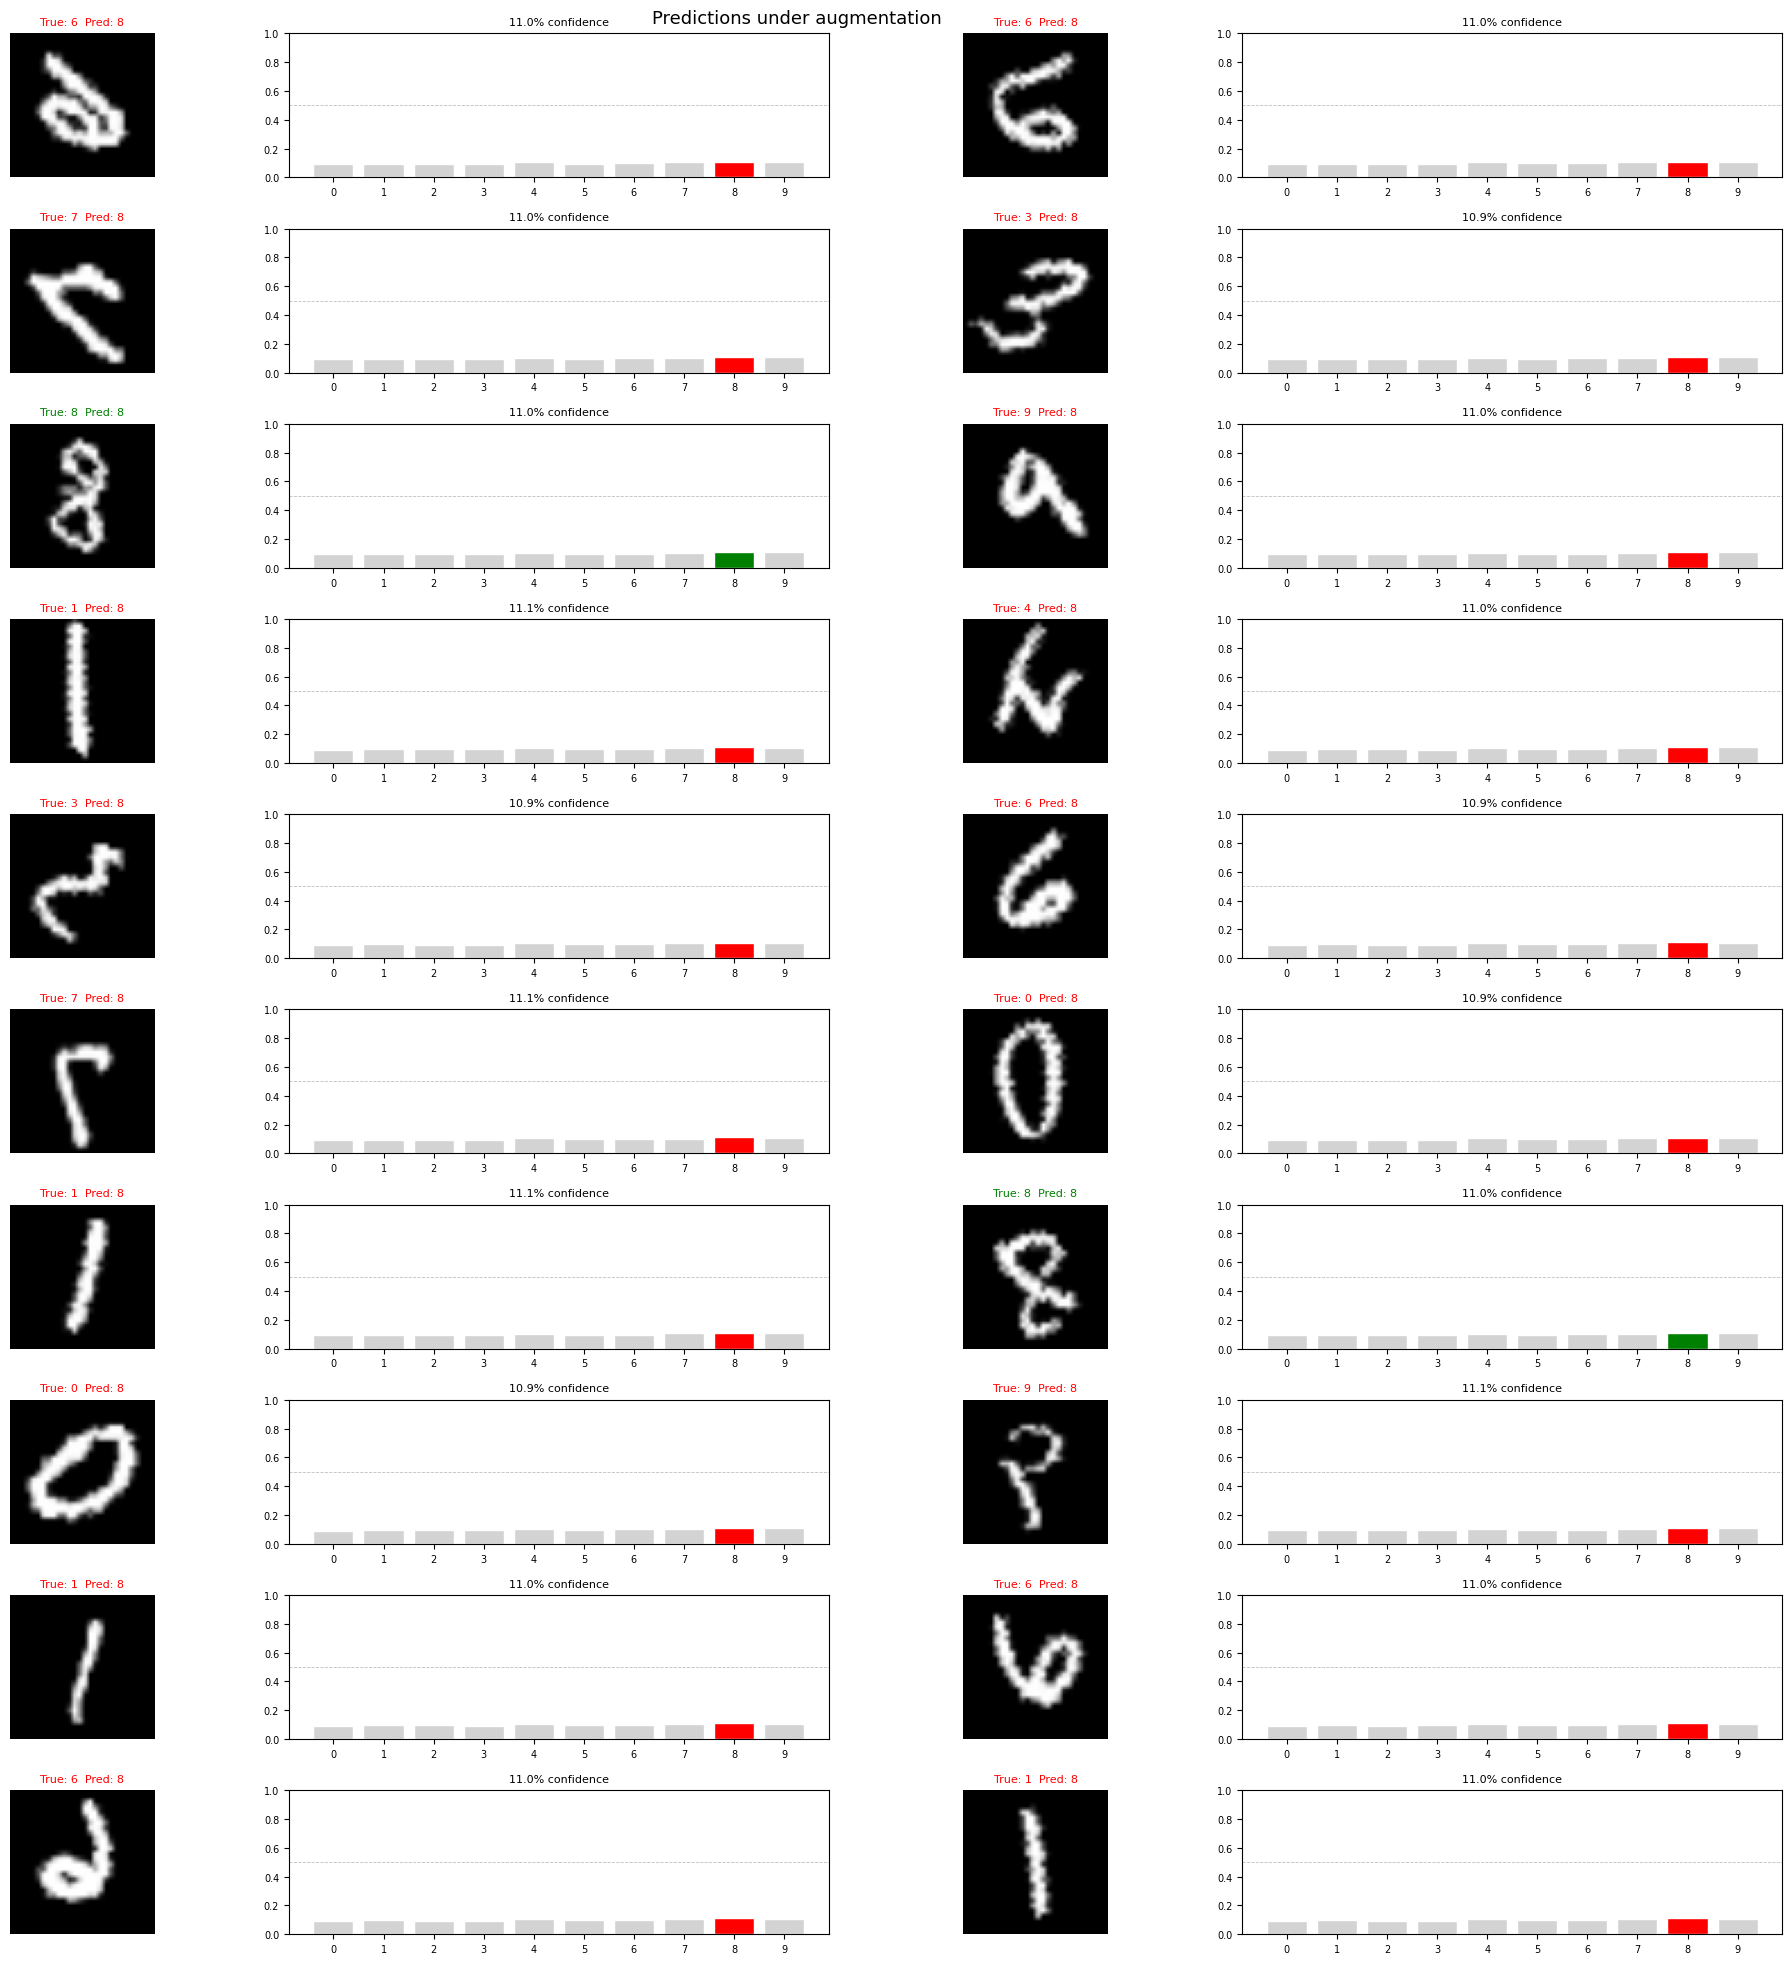

In [10]:
evaluate_under_augmentation(cnn)

In [ ]:
scores, labels = trainer.train(train_loader, val_loader)

Epoch   0 | Loss: 0.4610 | Statistic: 0.9959


Epoch   1 | Loss: 0.2362 | Statistic: 0.9981


  0%|          | 0/750 [00:00<?, ?it/s]

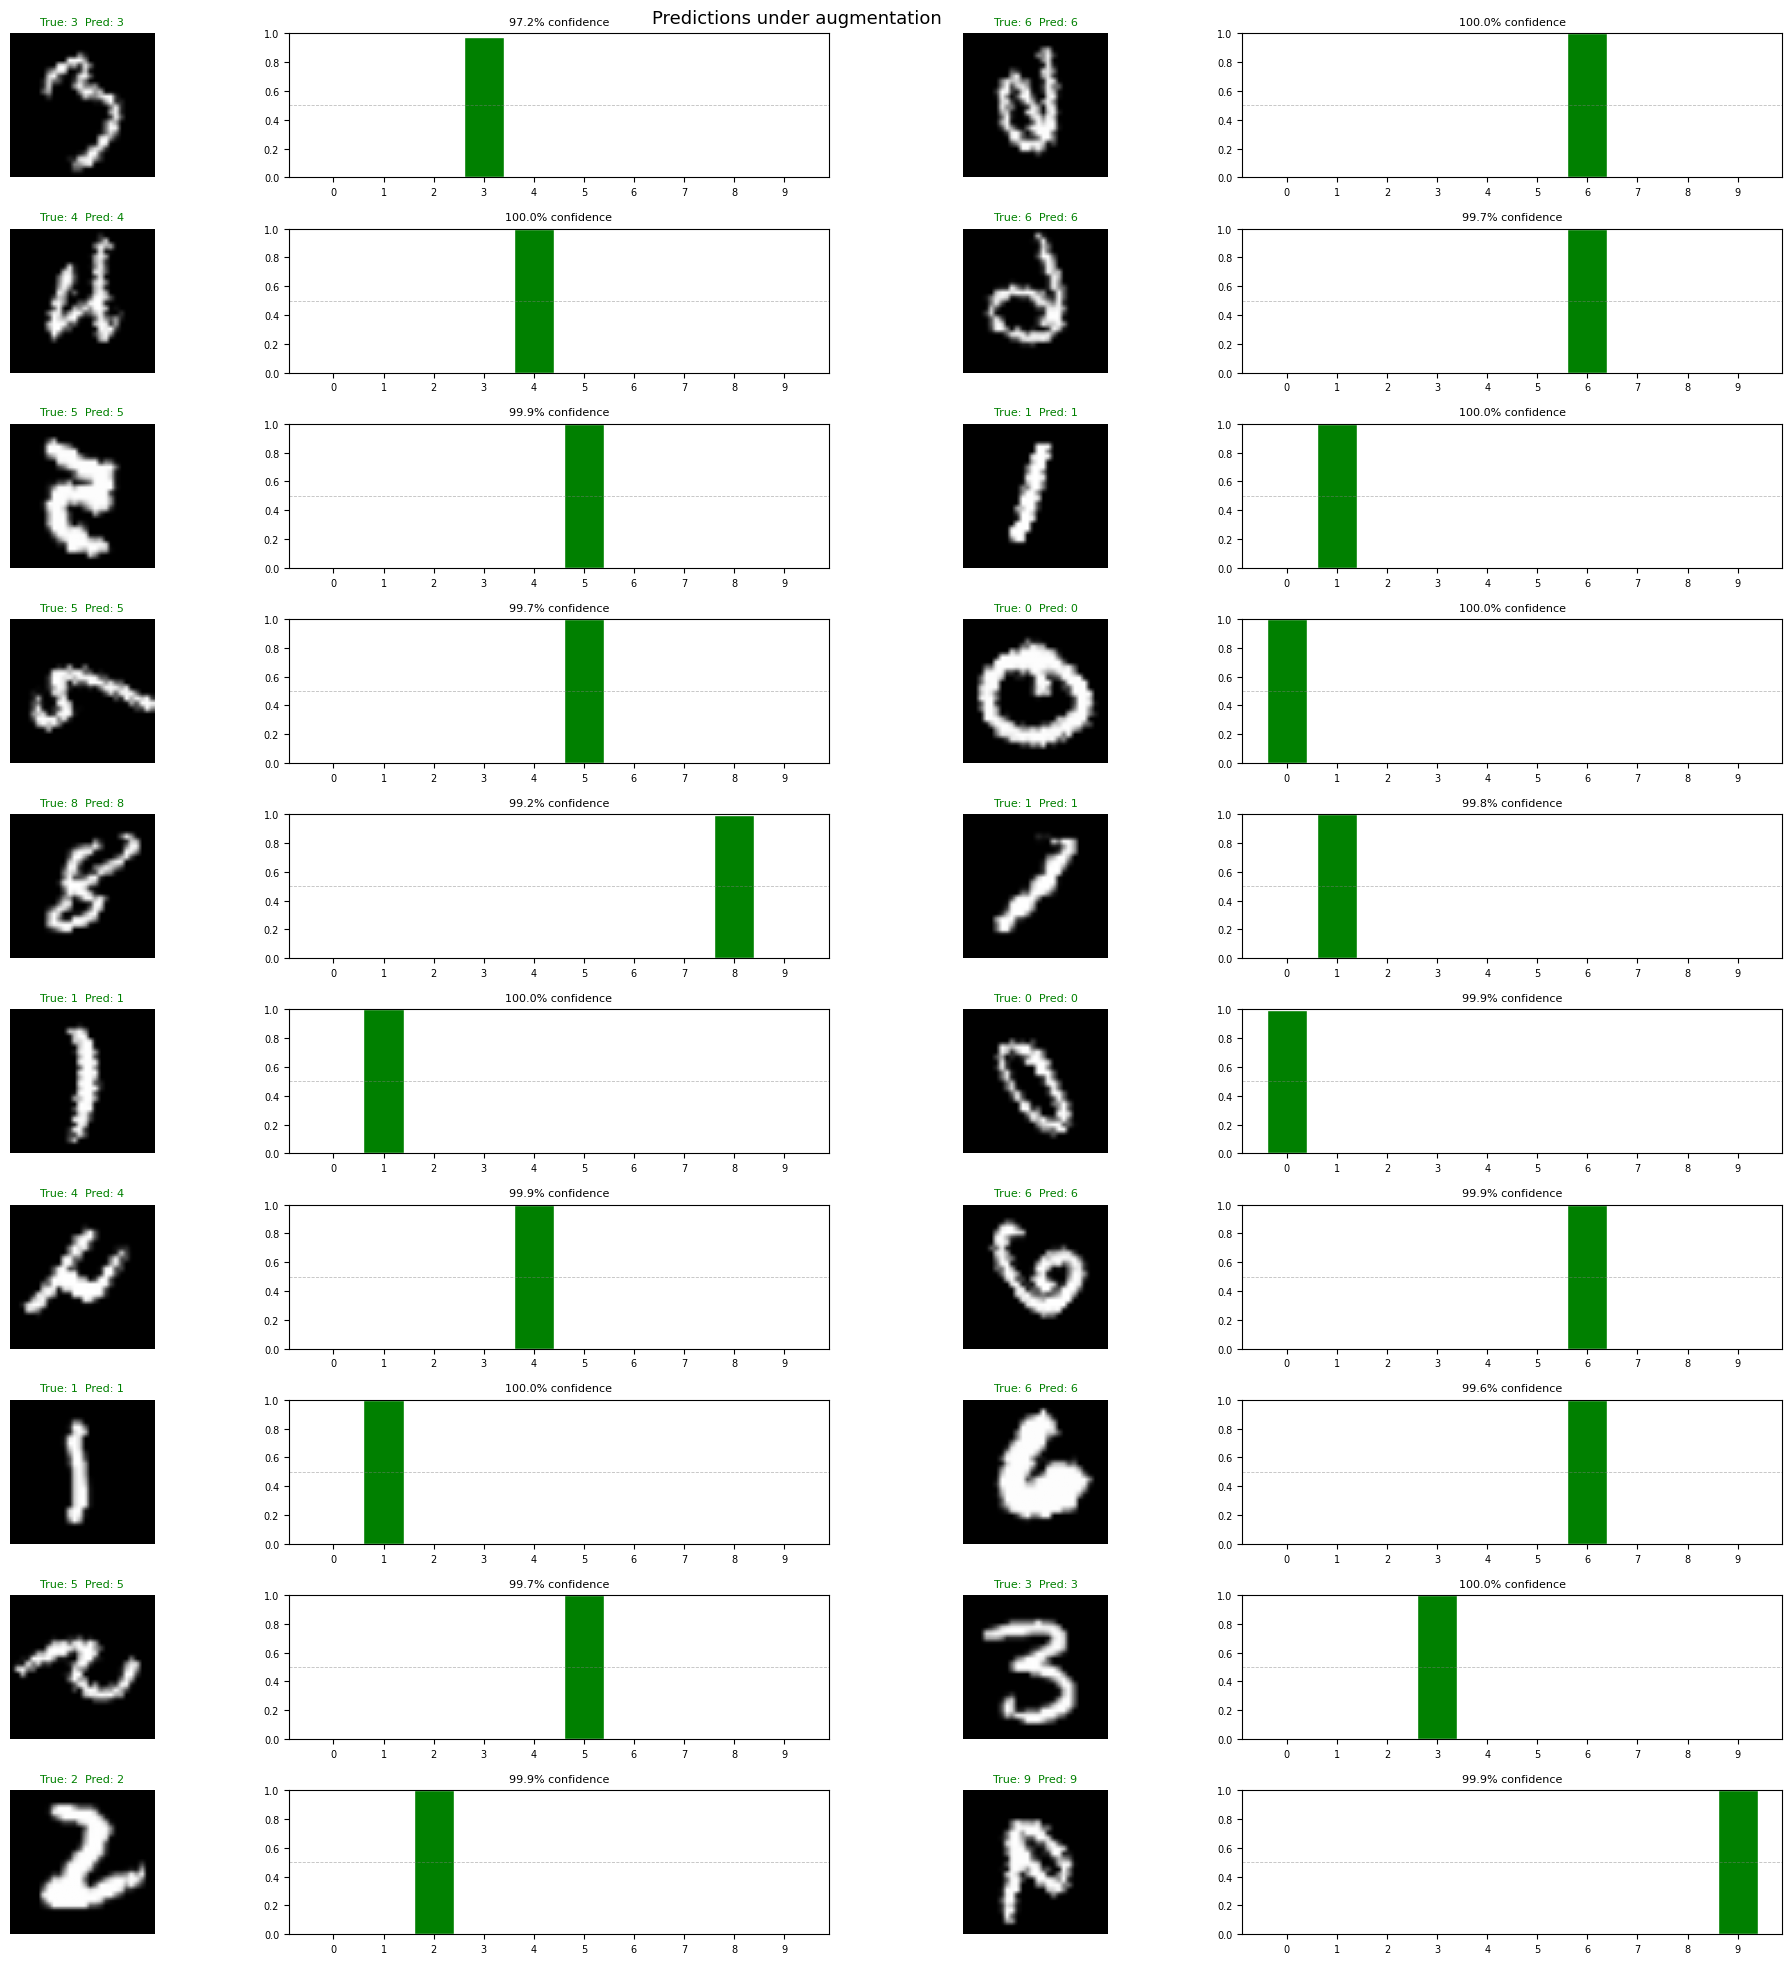

CNN(
  (conv): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): Dropout2d(p=0.1, inplace=False)
    (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): GELU(approximate='none')
    (8): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (9): Dropout2d(p=0.1, inplace=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=8192, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [ ]:
evaluate_under_augmentation(cnn)